# Background Information

This dataset comes from Kaggle and is compiled as part of the Abracadabra project. It contains approximately 550,000 Spotify tracks with lyrics, emotion labels, and audio features per song including tempo, energy, danceability, acousticness, and more. The dataset has 39 columns and utilizes a wide range of songs. 

Our central question is: **can audio features reveal something meaningful about the emotion of a song?** This is important because platforms like Spotify rely heavily on audio characteristics, such as tempo, key, loudness, and danceability, to suggest and curate playlist recomentations for users based on thier mood and listening habits.

If audio features can reliable capture emotional qualities, such as joy, saddness, anger, fear, love, or surprise, this would suggest that emotion is music is not entirely subjective but that it has measureable, underlying patterns. For example, usually faster tempos and beats are often associated with positive and energetic emotions. Slower, more softer songs are often associated with saddness. By identifying these patters, recommendation algorithms can generate playlists for users such as 'good-vibes', 'when i am sad', or 'hype me up' with greater precision. 

At the same time, personal experience plays as important role in music and how individuals interpret songs. This may not be captured in the data. This means that while audio features may provide useful signals about songs, they likely offer an incomplete picture of what emotion the song is. 

Exploring this question of if audio features can reveal the emotion of a song helps us understand data-driven recommendation systems and what features impact what emotion a song classifies as. We want to see if data along, not accounting for personal experience, can classify songs correctly.


We will approach this with two models:
1. **K-Means Clustering**: unsupervised exploration of whether songs naturally group into distinct audio profiles, and whether those groups align with the dataset's emotion labels
2. **Decision Tree**: a formal classification model to predict a song's emotion label from its audio features

# Imports and Load Data 

In [4]:
#load libraries
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score

In [5]:
# Load the dataset from Kaggle
# 1. This handles the login and download
# It will prompt you for your username and key from the json file
path = kagglehub.dataset_download("devdope/900k-spotify")

# 2. Load the specific CSV from that path
# The file in this dataset is named 'spotify_dataset.csv'
df = pd.read_csv(f"{path}/spotify_dataset.csv")

print(df.head())


  Artist(s)                       song  \
0       !!!  Even When the Waters Cold   
1       !!!         One Girl / One Boy   
2       !!!          Pardon My Freedom   
3       !!!                        Ooo   
4       !!!                 Freedom 15   

                                                text Length  emotion    Genre  \
0  Friends told her she was better off at the bot...  03:47  sadness  hip hop   
1  Well I heard it, playing soft From a drunken b...  04:03  sadness  hip hop   
2  Oh my god, did I just say that out loud? Shoul...  05:51      joy  hip hop   
3  [Verse 1] Remember when I called you on the te...  03:44      joy  hip hop   
4  [Verse 1] Calling me like I got something to s...  06:00      joy  hip hop   

           Album       Release Date     Key  Tempo  ...  \
0       Thr!!!er    29th April 2013   D min    105  ...   
1       Thr!!!er    29th April 2013  A# min    117  ...   
2  Louden Up Now      8th June 2004   A Maj    121  ...   
3          As If  16th O

# EDA

In [6]:
# explore the dataset's columns, non-null count, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null  str    
 12  Explicit                   

In [7]:
# get a summary statistics of the dataset
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# see the total na values in each column
df.isna().sum()

Artist(s)                          0
song                              16
text                               0
Length                             0
emotion                            0
Genre                              0
Album                             52
Release Date                       0
Key                                0
Tempo                              0
Loudness (db)                      0
Time signature                     8
Explicit                           0
Popularity                         0
Energy                             0
Danceability                       0
Positiveness                       0
Speechiness                        0
Liveness                           0
Acousticness                       0
Instrumentalness                   0
Good for Party                     0
Good for Work/Study                0
Good for Relaxation/Meditation     0
Good for Exercise                  0
Good for Running                   0
Good for Yoga/Stretching           0
G

In [9]:
# print column names
print(df.columns) 


Index(['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album',
       'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness',
       'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness',
       'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine',
       'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1',
       'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2',
       'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3'],
      dtype='str')


In [10]:
# create x and y dataset for modeling
y = df['emotion']

# drop emotion from X dataset along with columns not useful for modeling
X = df.drop(columns=['emotion',
                      'Similar Artist 1',
                      'Similar Artist 2',
                      'Similar Artist 3',
                      'Similar Song 1',
                      'Similar Song 2',
                      'Similar Song 3',
                      'Similarity Score 1',
                      'Similarity Score 2',
                      'Similarity Score 3',
                      'Album',
                      'song',
                      'Artist(s)',
                      'text'])

In [11]:
# view the columns in X to make sure columns were dropped
print(X.columns)
# see the distribution of the target variable
print(y.value_counts())
# print the shape of X and y to confirm they are the same length
print(X.shape)
print(y.shape)

Index(['Length', 'Genre', 'Release Date', 'Key', 'Tempo', 'Loudness (db)',
       'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability',
       'Positiveness', 'Speechiness', 'Liveness', 'Acousticness',
       'Instrumentalness', 'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine'],
      dtype='str')
emotion
joy          209009
sadness      171078
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64
(551443, 25)
(551443,)


In [12]:
# get the number of unique values in the target variable and the count of each value
print(y.nunique())
print(y.value_counts())

13
emotion
joy          209009
sadness      171078
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64


In [14]:
# group the less common emotions into an 'other' category to simplify the target variable
y = y.replace('Love', 'love')
y = y.replace('angry', 'anger')
y = y.replace(['True', 'pink', 'thirst', 'confusion', 'interest'], 'other')
# reprint to verify the changes
print(y.value_counts())


emotion
joy         209009
sadness     171078
anger       109679
fear         28097
love         27966
surprise      5592
other           22
Name: count, dtype: int64


### Graphs with an Emphasis on Variables we Believe to be Important For Analysis

<Axes: xlabel='Danceability', ylabel='Count'>

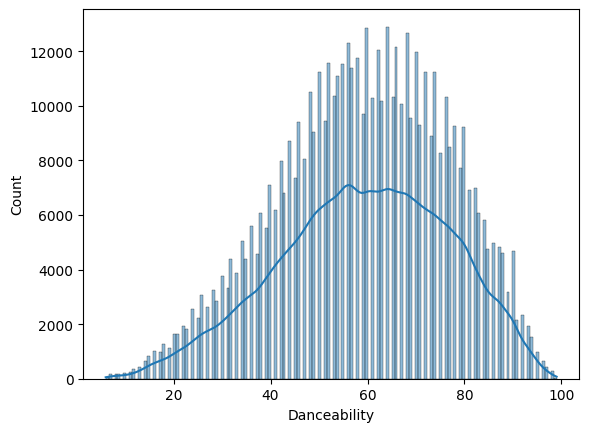

In [16]:
# plot a histogram of the danceability feature to see its distribution
sns.histplot(X['Danceability'], kde=True)

<Axes: xlabel='Tempo', ylabel='Count'>

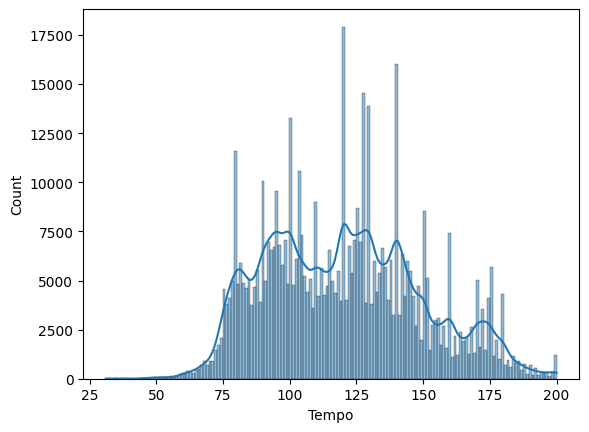

In [17]:
# plot a histogram of the Tempo feature to see its distribution
sns.histplot(X['Tempo'], kde=True)

<Axes: xlabel='Loudness (db)', ylabel='Count'>

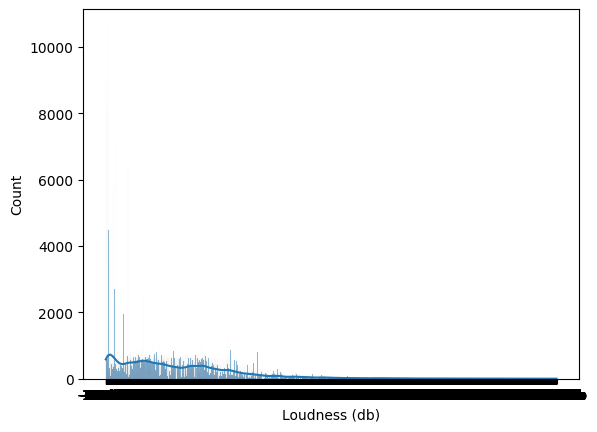

In [18]:
# plot a histogram of the Loudness (db) feature to see its distribution
sns.histplot(X['Loudness (db)'], kde=True)

<Axes: xlabel='Energy', ylabel='Count'>

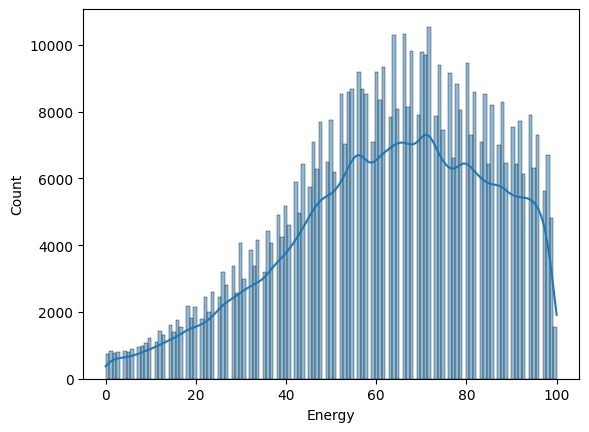

In [19]:
# plot a histogram of the energy feature to see its distribution
sns.histplot(X['Energy'], kde=True)